# Mô tả dữ liệu

## Hiện thị dữ liệu mẫu

In [ ]:
print(" Users DataFrame")
display(users_df.head())
print("\n Movies DataFrame")
display(movies_df.head())
print("\n Ratings DataFrame")
display(ratings_df.head())
print("\n Links DataFrame")
display(links_df.head())
print("\n User Actions DataFrame")
display(user_actions_df.head())

 Users DataFrame


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,Under 18,K-12 student,48067
1,2,M,56+,self-employed,70072
2,3,M,25-34,scientist,55117
3,4,M,45-49,executive/managerial,02460
4,5,M,25-34,writer,55455



 Movies DataFrame


,ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



 Ratings DataFrame


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291



 Links DataFrame


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0



 User Actions DataFrame


,id,name,weight
0,1,play_movie,2.5
1,2,play_25_percent,3.0
2,3,play_50_percent,3.5
3,4,play_75_percent,4.0
4,5,complete_movie,5.0


## Thống kê số lượng dữ liệu

In [ ]:
print("\n Số lượng dữ liệu")
print(f"Số lượng user   : {users_df.shape[0]}")
print(f"Số lượng movie  : {movies_df.shape[0]}")
print(f"Số lượng rating : {ratings_df.shape[0]}")



 Số lượng dữ liệu
Số lượng user   : 6040
Số lượng movie  : 3883
Số lượng rating : 1000209


## Thông tin dữ liệu

In [ ]:
print("\n Info Users ")
users_df.info()
print("\n Info Movies")
movies_df.info()
print("\n Info Ratings")
ratings_df.info()


 Info Users 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   object
 3   Occupation  6040 non-null   object
 4   Zip-code    6040 non-null   object
dtypes: int64(1), object(4)
memory usage: 236.1+ KB

 Info Movies
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      3883 non-null   int64 
 1   Title   3883 non-null   object
 2   Genres  3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB

 Info Ratings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------

## Thống kê phân tích cơ bản

In [ ]:
print("\n Thống kê rating toàn hệ thống")
print(ratings_df['Rating'].describe())
print("\n Trung bình rating theo user")
print(ratings_df.groupby('UserID')['Rating'].mean().describe())
print("\n Trung bình rating theo movie")
print(ratings_df.groupby('MovieID')['Rating'].mean().describe())


 Thống kê rating toàn hệ thống
count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64

 Trung bình rating theo user
count    6040.000000
mean        3.702705
std         0.429622
min         1.015385
25%         3.444444
50%         3.735294
75%         4.000000
max         4.962963
Name: Rating, dtype: float64

 Trung bình rating theo movie
count    3706.000000
mean        3.238892
std         0.672925
min         1.000000
25%         2.822705
50%         3.331546
75%         3.740741
max         5.000000
Name: Rating, dtype: float64


## Kiểm tra tỉ lệ missing value

In [ ]:
dfs = {
    "Users": users_df,
    "Movies": movies_df,
    "Ratings": ratings_df,
    "Links": links_df,
    "User Actions": user_actions_df
}
for name, df in dfs.items():
    print(name)
    display(df.isna().mean())
    print()


Users


,0
UserID,0.0
Gender,0.0
Age,0.0
Occupation,0.0
Zip-code,0.0



Movies


,0
ID,0.0
Title,0.0
Genres,0.0



Ratings


,0
UserID,0.0
MovieID,0.0
Rating,0.0
Timestamp,0.0



Links


,0
movieId,0.000000
imdbId,0.000000
tmdbId,0.000821



User Actions


,0
id,0.0
name,0.0
weight,0.0


## Phân bố Ratings

/tmp/ipython-input-3284886073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=ratings_df, palette='viridis')


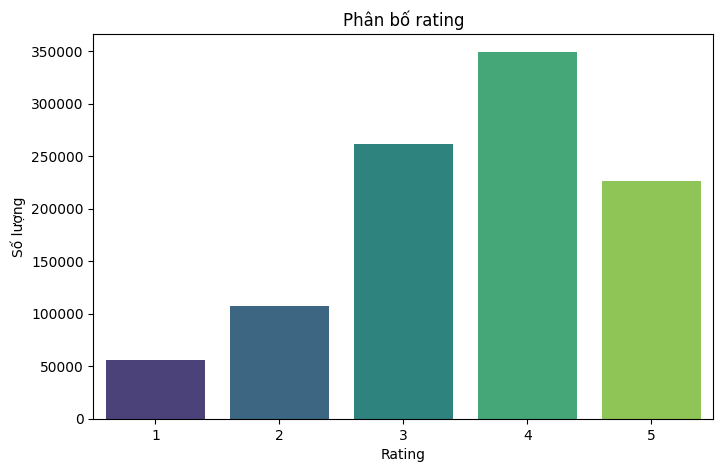

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=ratings_df, palette='viridis')
plt.title("Phân bố rating")
plt.xlabel("Rating")
plt.ylabel("Số lượng")
plt.show()


## Số lượng Rating trên mỗi User

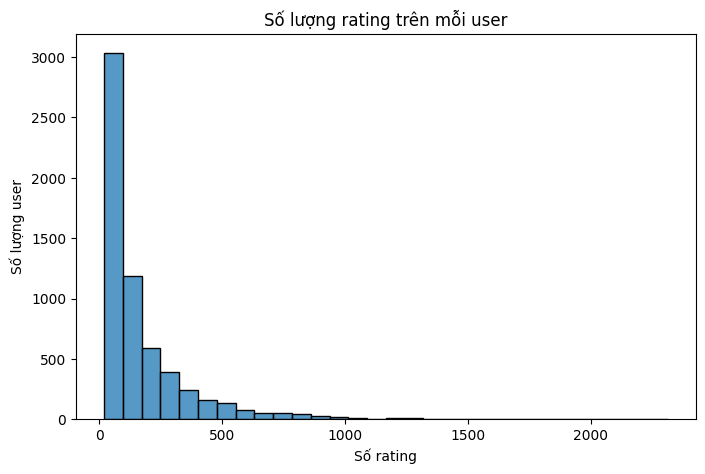

In [ ]:
ratings_per_user = ratings_df.groupby('UserID').size()
plt.figure(figsize=(8,5))
sns.histplot(ratings_per_user, bins=30, kde=False)
plt.title("Số lượng rating trên mỗi user")
plt.xlabel("Số rating")
plt.ylabel("Số lượng user")
plt.show()

## Số lượng Rating trên mỗi Movie

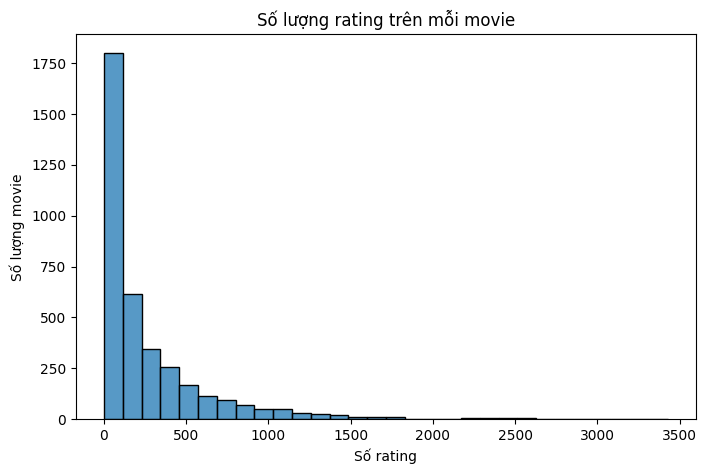

In [ ]:
ratings_per_movie = ratings_df.groupby('MovieID').size()
plt.figure(figsize=(8,5))
sns.histplot(ratings_per_movie, bins=30, kde=False)
plt.title("Số lượng rating trên mỗi movie")
plt.xlabel("Số rating")
plt.ylabel("Số lượng movie")
plt.show()

## Lấy top 10 Genres phổ biến nhất

/tmp/ipython-input-720422573.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[g[0] for g in top_genres], y=[g[1] for g in top_genres], palette='magma')


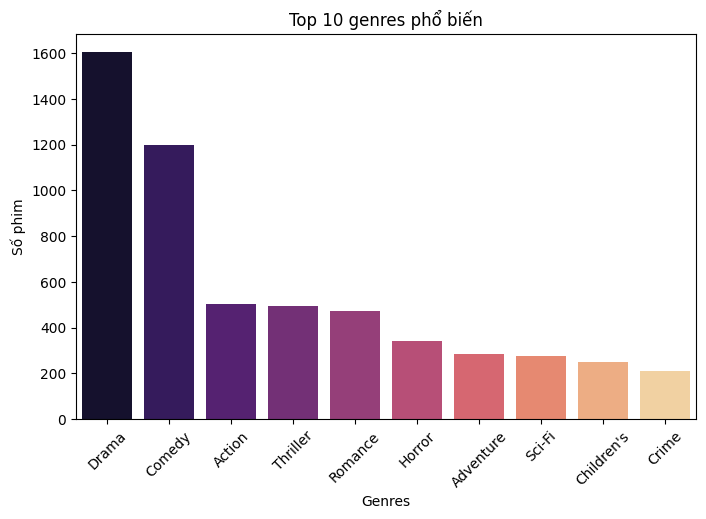

In [ ]:
from collections import Counter

all_genres = movies_df['Genres'].str.split('|').sum()
genre_counts = Counter(all_genres)
top_genres = genre_counts.most_common(10)

plt.figure(figsize=(8,5))
sns.barplot(x=[g[0] for g in top_genres], y=[g[1] for g in top_genres], palette='magma')
plt.title("Top 10 genres phổ biến")
plt.xlabel("Genres")
plt.ylabel("Số phim")
plt.xticks(rotation=45)
plt.show()

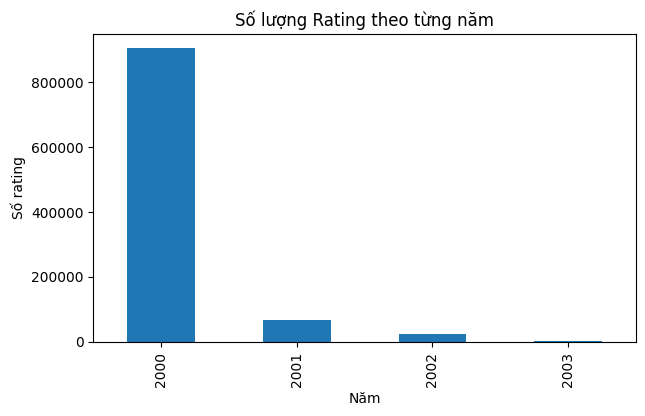

In [ ]:
ratings_df['Timestamp'] = pd.to_datetime(ratings_df['Timestamp'], unit='s')

rating_by_year = ratings_df.groupby(ratings_df['Timestamp'].dt.year)['Rating'].count()

plt.figure(figsize=(7,4))
rating_by_year.plot(kind='bar')
plt.title("Số lượng Rating theo từng năm")
plt.ylabel("Số rating")
plt.xlabel("Năm")
plt.show()
